# Examen Parcial 1: Aprendizaje Federado, Privacidad y Regresión Logística con Census Income

## Tabla de Contenido

1. [Importación de Librerías y Configuración](#sec-imports)
2. [Carga y Preparación del Dataset](#sec-data)
3. [Análisis Exploratorio de Datos (EDA)](#sec-eda)
4. [Análisis de Privacidad](#sec-privacy-analysis)
5. [Preprocesamiento](#sec-preprocessing)
6. [Experimento 1 — Centralizado con Datos Originales (Baseline)](#sec-exp1)
7. [Experimento 2 — Centralizado con Datos Protegidos](#sec-exp2)
8. [Experimento 3 — Aprendizaje Federado con Datos Originales](#sec-exp3)
9. [Experimento 4 — Datos Sintéticos + Aprendizaje Federado](#sec-exp4)
10. [Experimento 5 — Protección de Parámetros + Aprendizaje Federado](#sec-exp5)
11. [Comparación Final](#sec-comparison)
12. [Preguntas de Análisis](#sec-questions)
13. [Conclusiones](#sec-conclusions)

<a id='sec-imports'></a>
## 1. Importación de Librerías y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, copy, warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
warnings.filterwarnings('ignore', category=FutureWarning)
SEED=42
np.random.seed(SEED)
plt.rcParams['figure.figsize']=(10,6); plt.rcParams['font.size']=12
sns.set_style('whitegrid'); sns.set_palette('husl')
print('Librerias importadas; seed:', SEED)

Librerias importadas; seed: 42


<a id='sec-data'></a>
## 2. Carga y Preparación del Dataset

El dataset **Adult / Census Income** (también conocido como "Census Income") fue extraído de la base de datos del censo de EE.UU. en 1994. La tarea de predicción es determinar si el ingreso de una persona supera los $50,000 anuales.

- **Clase objetivo:** `income` → `<=50K` (0) / `>50K` (1)

In [2]:
from pathlib import Path
DATA_DIR = Path.cwd()
COLUMNS = ['age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income']
train_path, test_path = DATA_DIR/'adult.data', DATA_DIR/'adult.test'
if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(f'Coloca adult.data y adult.test junto al notebook ({DATA_DIR}).')
train_df = pd.read_csv(train_path, names=COLUMNS, skipinitialspace=True)
test_df = pd.read_csv(test_path, names=COLUMNS, skipinitialspace=True, skiprows=1)
print('Train:', train_df.shape, '| Test:', test_df.shape, '| Total:', len(train_df)+len(test_df))

Train: (32561, 15) | Test: (16281, 15) | Total: 48842


In [3]:

test_df['income'] = test_df['income'].str.replace('.', '', regex=False)
print('Valores de income en train:', train_df['income'].unique())
print('Valores de income en test: ', test_df['income'].unique())

Valores de income en train: ['<=50K' '>50K']
Valores de income en test:  ['<=50K' '>50K']


In [4]:
train_df=train_df.copy(); test_df=test_df.copy()
train_df.replace('?',np.nan,inplace=True); test_df.replace('?',np.nan,inplace=True)
print('Faltantes train:'); display(train_df.isna().sum().sort_values(ascending=False))
print('Faltantes test:'); display(test_df.isna().sum().sort_values(ascending=False))
train_clean=train_df.reset_index(drop=True); test_clean=test_df.reset_index(drop=True)
print(f'Filas conservadas: train={len(train_clean)}, test={len(test_clean)}')

Faltantes train:


occupation        1843
workclass         1836
native-country     583
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64

Faltantes test:


occupation        966
workclass         963
native-country    274
fnlwgt              0
education           0
education-num       0
age                 0
marital-status      0
relationship        0
sex                 0
race                0
capital-gain        0
capital-loss        0
hours-per-week      0
income              0
dtype: int64

Filas conservadas: train=32561, test=16281


In [5]:

label_map = {'<=50K': 0, '>50K': 1}
train_clean['income_binary'] = train_clean['income'].map(label_map)
test_clean['income_binary'] = test_clean['income'].map(label_map)

print('Distribucion de la variable objetivo (train):')
print(train_clean['income_binary'].value_counts())
print(f'\nProporcion >50K: {train_clean["income_binary"].mean():.4f}')

Distribucion de la variable objetivo (train):
income_binary
0    24720
1     7841
Name: count, dtype: int64

Proporcion >50K: 0.2408


In [6]:

numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

print('Variables numericas:', numerical_cols)
print(f'  Total: {len(numerical_cols)}')
print('\nVariables categoricas:', categorical_cols)
print(f'  Total: {len(categorical_cols)}')

Variables numericas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
  Total: 6

Variables categoricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
  Total: 8


In [7]:
display(train_clean.head())
print('\nEstadisticas descriptivas (variables numericas):')
display(train_clean[numerical_cols].describe())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0



Estadisticas descriptivas (variables numericas):


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


<a id='sec-eda'></a>
## 3. Análisis Exploratorio de Datos (EDA)

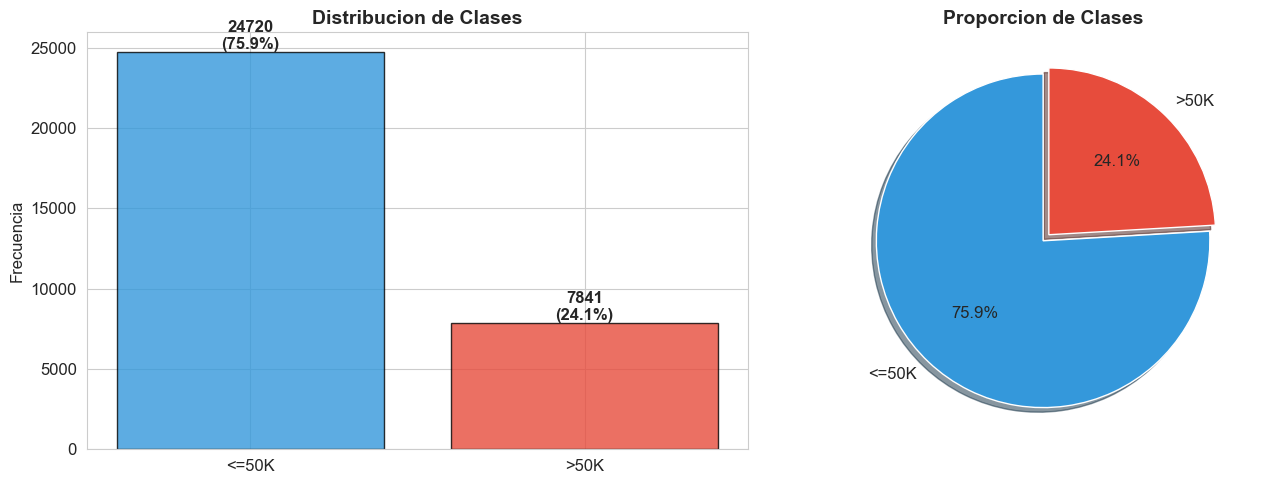


Observacion: El dataset esta DESBALANCEADO (~75% <=50K vs ~25% >50K).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras
class_counts = train_clean['income'].value_counts()
colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribucion de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val}\n({val/len(train_clean)*100:.1f}%)', ha='center', fontweight='bold')

# Grafico de pastel
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Proporcion de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nObservacion: El dataset esta DESBALANCEADO (~75% <=50K vs ~25% >50K).')

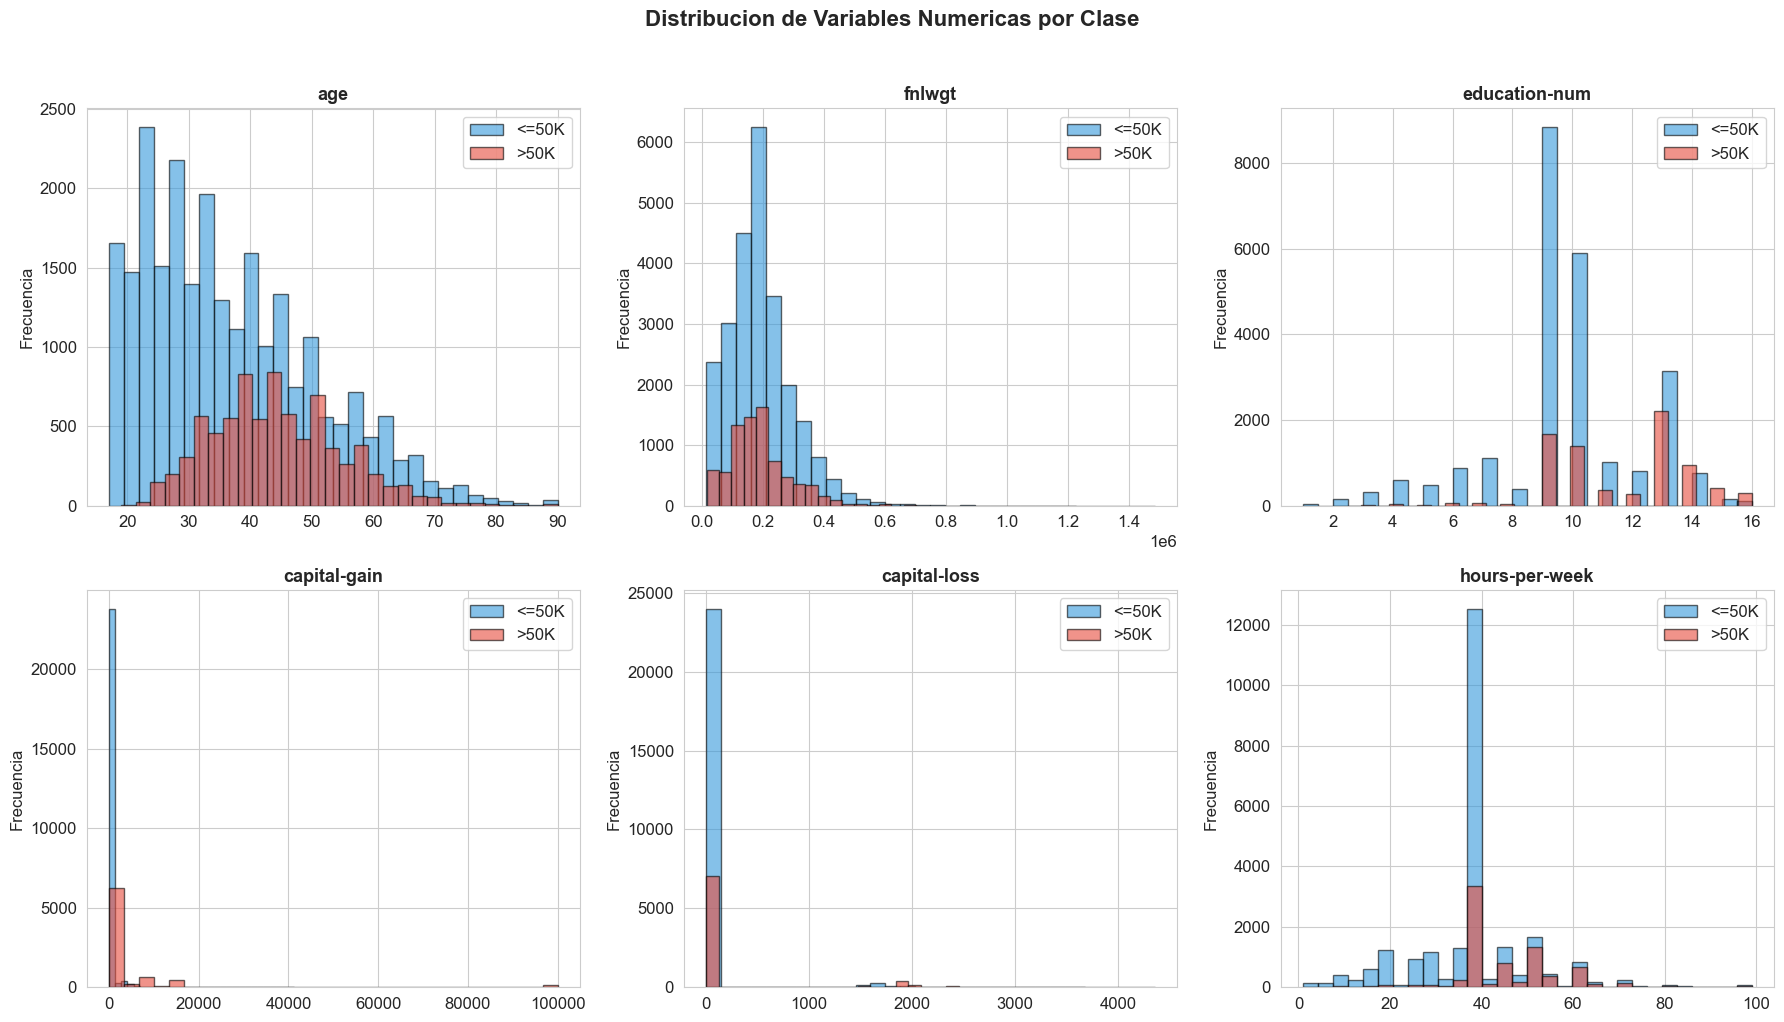

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for label, color in zip(['<=50K', '>50K'], ['#3498db', '#e74c3c']):
        subset = train_clean[train_clean['income'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribucion de Variables Numericas por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

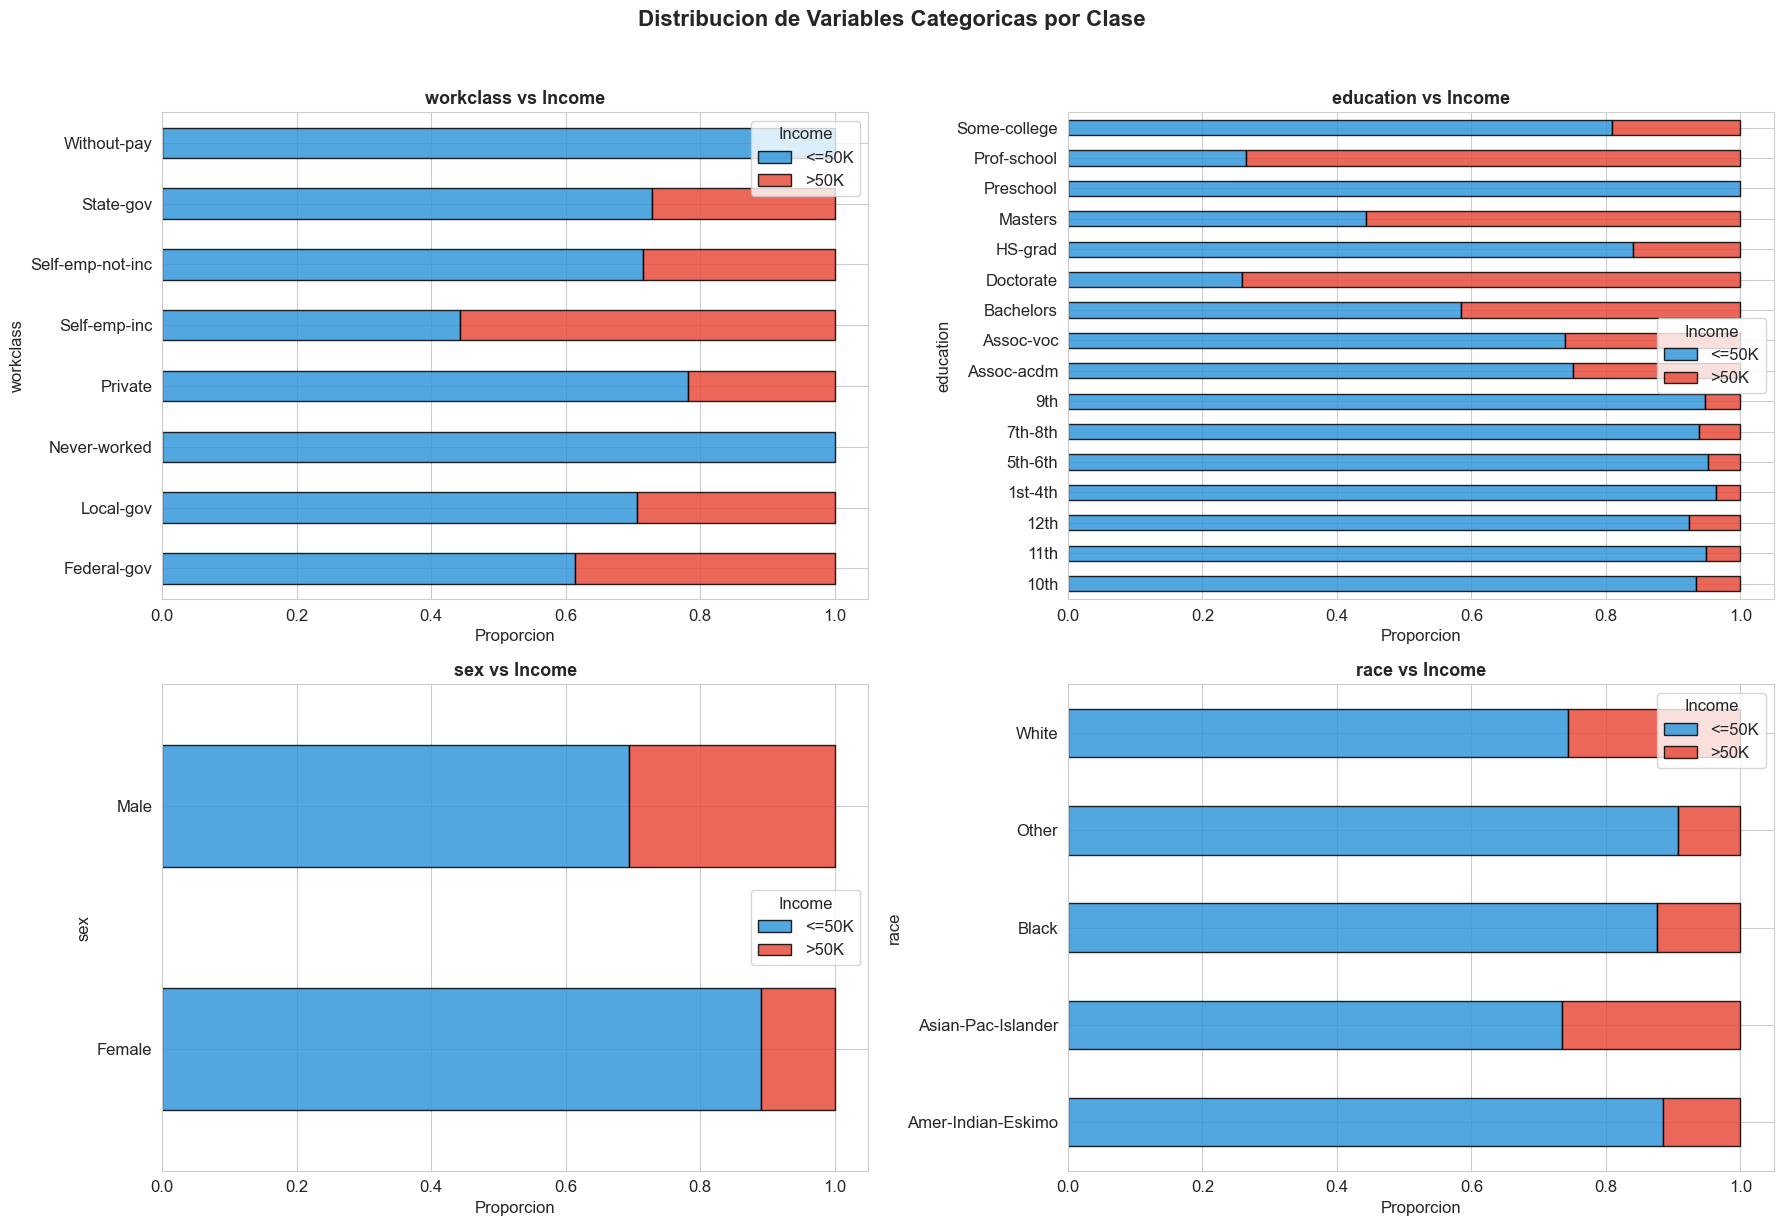

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

cat_to_plot = ['workclass', 'education', 'sex', 'race']
for i, col in enumerate(cat_to_plot):
    ct = pd.crosstab(train_clean[col], train_clean['income'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'],
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} vs Income', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Proporcion')
    axes[i].legend(title='Income')

plt.suptitle('Distribucion de Variables Categoricas por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

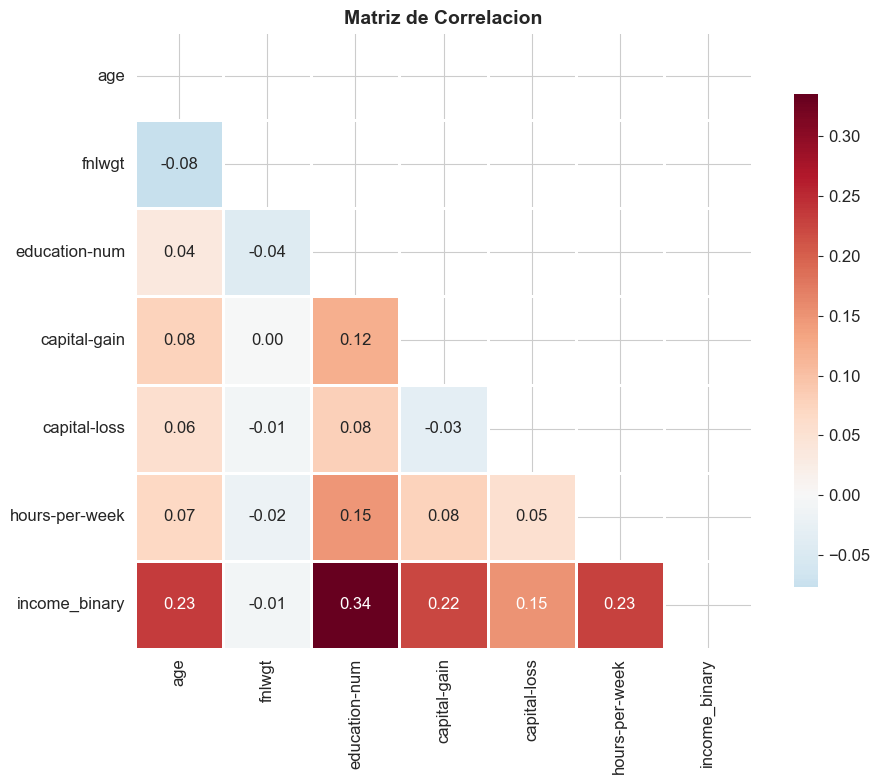

In [11]:


corr_df = train_clean[numerical_cols + ['income_binary']].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='sec-privacy-analysis'></a>
## 4. Análisis de Privacidad

Identificamos posibles riesgos de privacidad en el dataset.

In [12]:
sensitive_attrs={'race':'Raza o etnia registrada','sex':'Sexo registrado','marital-status':'Estado civil registrado','native-country':'Pais de origen registrado','income':'Nivel de ingresos (objetivo)'}
for attr,desc in sensitive_attrs.items():
    print(f'\n[SENSIBLE] {attr}: {desc}; valores={train_clean[attr].nunique()}')
print('fnlwgt es un peso muestral censal, no un identificador personal directo.')


[SENSIBLE] race: Raza o etnia registrada; valores=5

[SENSIBLE] sex: Sexo registrado; valores=2

[SENSIBLE] marital-status: Estado civil registrado; valores=7

[SENSIBLE] native-country: Pais de origen registrado; valores=41

[SENSIBLE] income: Nivel de ingresos (objetivo); valores=2
fnlwgt es un peso muestral censal, no un identificador personal directo.


In [13]:

print('=' * 60)
print('CUASI-IDENTIFICADORES')
print('=' * 60)
quasi_ids = {
    'age': 'Edad (puede combinarse con otros atributos para reidentificar)',
    'education': 'Nivel educativo',
    'occupation': 'Ocupacion',
    'workclass': 'Tipo de empleo',
    'hours-per-week': 'Horas de trabajo semanales',
    'native-country': 'Pais de origen',
    'sex': 'Sexo registrado',
    'race': 'Raza o etnia registrada'
}
for attr, desc in quasi_ids.items():
    print(f'\n  [QUASI-ID] {attr}: {desc}')
    print(f'     Valores unicos: {train_clean[attr].nunique()}')
quantitative_qi = ['age', 'sex', 'race', 'education', 'occupation', 'native-country']
print('\nCombinacion usada para medir singularidad k=1:', ' + '.join(quantitative_qi))

CUASI-IDENTIFICADORES

  [QUASI-ID] age: Edad (puede combinarse con otros atributos para reidentificar)
     Valores unicos: 73

  [QUASI-ID] education: Nivel educativo
     Valores unicos: 16

  [QUASI-ID] occupation: Ocupacion
     Valores unicos: 14

  [QUASI-ID] workclass: Tipo de empleo
     Valores unicos: 8

  [QUASI-ID] hours-per-week: Horas de trabajo semanales
     Valores unicos: 94

  [QUASI-ID] native-country: Pais de origen
     Valores unicos: 41

  [QUASI-ID] sex: Sexo registrado
     Valores unicos: 2

  [QUASI-ID] race: Raza o etnia registrada
     Valores unicos: 5

Combinacion usada para medir singularidad k=1: age + sex + race + education + occupation + native-country


In [14]:
quasi_id_cols=['age','sex','race','education','occupation','native-country']
group_sizes=train_clean.groupby(quasi_id_cols,dropna=False).size()
unique_records=int((group_sizes==1).sum())
print('INDICADOR DE SINGULARIDAD')
print(f'Registros con combinacion k=1: {unique_records} ({unique_records/len(train_clean)*100:.2f}%)')
print(f'Tamano minimo={group_sizes.min()}, mediano={group_sizes.median():.2f}')
print('k=1 no demuestra reidentificacion real; haria falta informacion auxiliar adecuada.')

INDICADOR DE SINGULARIDAD
Registros con combinacion k=1: 8054 (24.74%)
Tamano minimo=1, mediano=1.00
k=1 no demuestra reidentificacion real; haria falta informacion auxiliar adecuada.


<a id='sec-preprocessing'></a>
## 5. Preprocesamiento

Creamos una función de preprocesamiento reutilizable para mantener la consistencia entre todos los experimentos.

In [15]:
def preprocess_data(train_data,test_data,numerical_cols,categorical_cols):
    Xtr=train_data[numerical_cols+categorical_cols].copy(); Xte=test_data[numerical_cols+categorical_cols].copy()
    ytr=train_data['income_binary'].to_numpy(); yte=test_data['income_binary'].to_numpy()
    num=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
    cat=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
    prep=ColumnTransformer([('num',num,numerical_cols),('cat',cat,categorical_cols)])
    Xtrp=prep.fit_transform(Xtr); Xtep=prep.transform(Xte)
    names=list(numerical_cols)+list(prep.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))
    return Xtrp,Xtep,ytr,yte,prep,names

In [16]:

def evaluate_model(model, X_test, y_test, experiment_name=''):
    """
    Evalua un modelo y retorna un diccionario con las metricas.
    Tambien muestra la matriz de confusion.
    """
    y_pred = model.predict(X_test)
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }
    
    print(f'\n{"=" * 60}')
    print(f'  Resultados: {experiment_name}')
    print(f'{"=" * 60}')
    for metric, value in metrics.items():
        print(f'  {metric:>12}: {value:.4f}')
    
    print(f'\n{classification_report(y_test, y_pred, target_names=["<=50K", ">50K"])}')
    
    # Matriz de confusion
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Matriz de Confusion - {experiment_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return metrics

print('Funcion de evaluacion definida.')

Funcion de evaluacion definida.


In [17]:

X_train, X_test, y_train, y_test, preprocessor, feature_names = preprocess_data(
    train_clean, test_clean, numerical_cols, categorical_cols
)

print(f'Dimensiones tras preprocesamiento:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  Numero de features: {len(feature_names)}')

Dimensiones tras preprocesamiento:
  X_train: (32561, 105)
  X_test:  (16281, 105)
  Numero de features: 105



  Resultados: Baseline trivial: clase mayoritaria
      Accuracy: 0.7638
     Precision: 0.0000
        Recall: 0.0000
            F1: 0.0000

              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.87     12435
        >50K       0.00      0.00      0.00      3846

    accuracy                           0.76     16281
   macro avg       0.38      0.50      0.43     16281
weighted avg       0.58      0.76      0.66     16281



c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

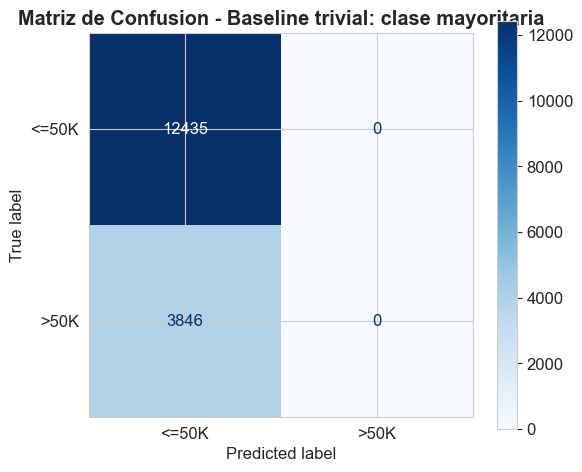

In [18]:
assert set(np.unique(y_train))=={0,1}
assert set(np.unique(y_test))=={0,1}
assert X_train.shape[0]==len(y_train) and X_test.shape[0]==len(y_test)
assert X_train.shape[1]==len(feature_names)
dummy=DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
dummy_metrics=evaluate_model(dummy,X_test,y_test,'Baseline trivial: clase mayoritaria')

<a id='sec-exp1'></a>
## 6. Experimento 1 — Centralizado con Datos Originales (Baseline)

Entrenamos una `LogisticRegression` con los datos originales preprocesados. Este experimento servirá como **baseline** para comparar con los demás escenarios.

### Protocolo experimental
- Todos los escenarios se evalúan sobre las mismas 16,281 filas de prueba y usan `>50K = 1` como clase positiva. Precision, Recall y F1 se refieren a esa clase.
- Cada preprocesador se ajusta solo con sus datos de entrenamiento y luego transforma el conjunto de prueba. En Exp4, el preprocesador ajustado con el entrenamiento real conserva el mismo espacio de 105 características para los datos sintéticos y reales.
- Los experimentos federados usan 3 clientes, 10 rondas y FedAvg ponderado por la cantidad de registros de cada cliente.
- Se conserva la misma partición de prueba y la misma definición de las métricas para que los resultados sean comparables.


  Resultados: Exp1: Centralizado Original
      Accuracy: 0.8507
     Precision: 0.7282
        Recall: 0.5871
            F1: 0.6501

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     12435
        >50K       0.73      0.59      0.65      3846

    accuracy                           0.85     16281
   macro avg       0.80      0.76      0.78     16281
weighted avg       0.84      0.85      0.84     16281



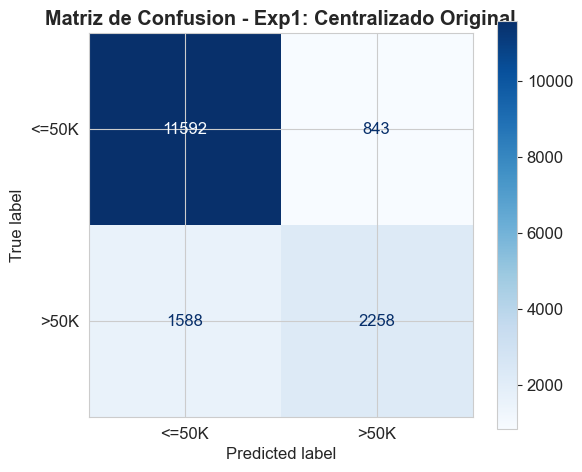

In [19]:

model_exp1 = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model_exp1.fit(X_train, y_train)

# Evaluar
metrics_exp1 = evaluate_model(model_exp1, X_test, y_test, 'Exp1: Centralizado Original')

coef_.shape: (1, 105) intercept_: [-1.66958134]


,feature,coefficient
0,age,0.305837
1,fnlwgt,0.072761
2,education-num,0.759014
3,capital-gain,2.304990
4,capital-loss,0.260291
...,...,...
100,native-country_Thailand,-0.229952
101,native-country_Trinadad&Tobago,-0.107132
102,native-country_United-States,0.322640
103,native-country_Vietnam,-0.846299


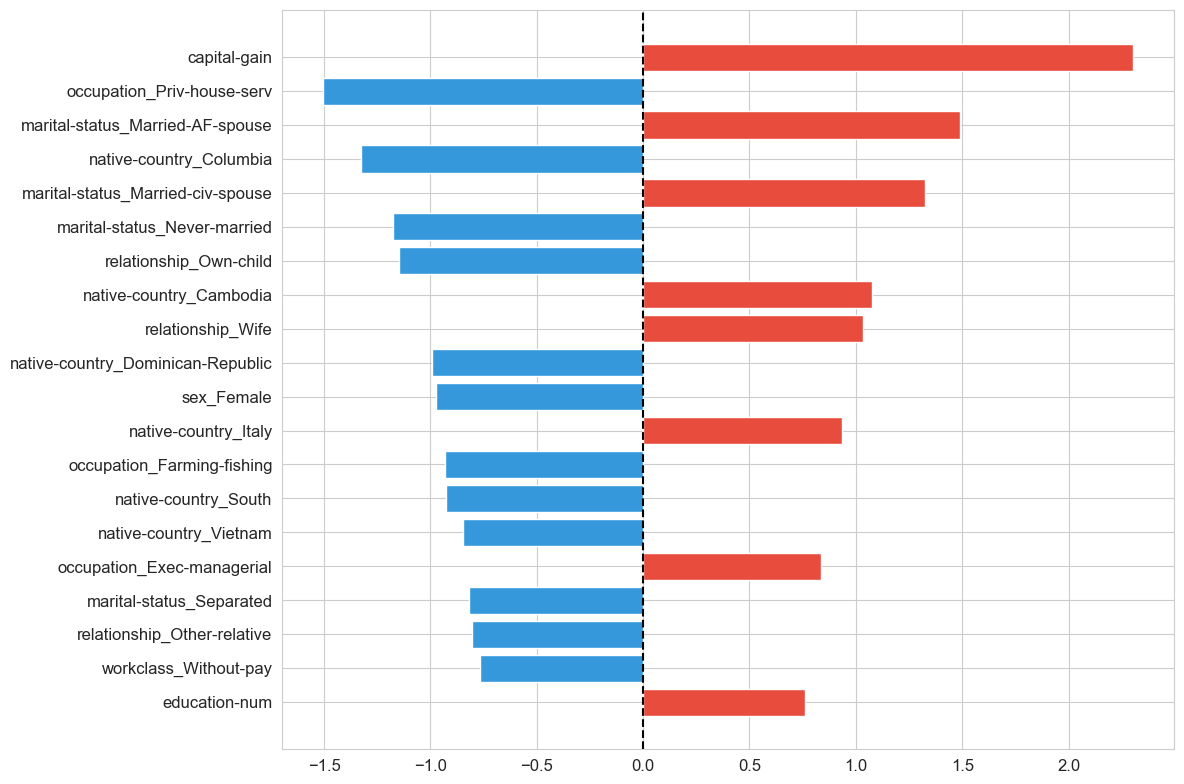

In [20]:
coef_df=pd.DataFrame({'feature':feature_names,'coefficient':model_exp1.coef_[0]})
print('coef_.shape:',model_exp1.coef_.shape,'intercept_:',model_exp1.intercept_)
display(coef_df)
top=coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(20)
fig,ax=plt.subplots(figsize=(12,8)); colors=['#e74c3c' if x>0 else '#3498db' for x in top.coefficient]
ax.barh(range(len(top)),top.coefficient,color=colors); ax.set_yticks(range(len(top))); ax.set_yticklabels(top.feature)
ax.axvline(0,color='black',linestyle='--'); ax.invert_yaxis(); plt.tight_layout(); plt.show()

<a id='sec-exp2'></a>
## 7. Experimento 2 — Centralizado con Datos Protegidos

Aplicamos **tres técnicas de anonimización/protección** a los datos originales antes de entrenar:

1. **Generalización** de `age` (agrupación en rangos de 10 años)
2. **Supresión** del atributo `native-country` (demasiado identificable)
3. **Agrupación de categorías raras** en `workclass`, `occupation` y `education` (frecuencia <1% agrupada como `Other`)

> **Nota:** `OneHotEncoder` por sí solo no se considera una técnica de anonimización.

In [21]:
RARE_THRESHOLD=0.01
GROUP_COLUMNS=['workclass','occupation','education']
def generalize_age(df):
    out=df.copy(); out['age']=pd.cut(out.age,bins=[0,20,30,40,50,60,70,80,100],labels=['0-20','21-30','31-40','41-50','51-60','61-70','71-80','81+']); return out
def fit_category_grouping_rules(df,columns,threshold=RARE_THRESHOLD):
    return {c:set((v:=df[c].fillna('Unknown').value_counts(normalize=True))[v>=threshold].index) for c in columns}
def apply_category_grouping(df,rules):
    out=df.copy()
    for c,allowed in rules.items():
        vals=out[c].fillna('Unknown'); out[c]=vals.where(vals.isin(allowed),'Other')
    return out
def suppress_country(df):
    out=df.copy(); out['native-country']='SUPPRESSED'; return out

In [22]:
category_rules=fit_category_grouping_rules(train_clean,GROUP_COLUMNS)
def protect_dataset(df):
    out=apply_category_grouping(suppress_country(generalize_age(df)),category_rules); out['age']=out['age'].astype('object').fillna('Unknown').astype(str); return out
train_anon=protect_dataset(train_clean); test_anon=protect_dataset(test_clean)

In [23]:
numerical_cols_anon=[c for c in numerical_cols if c != 'age']
categorical_cols_anon=categorical_cols+['age']
X_train_anon,X_test_anon,y_train_anon,y_test_anon,preprocessor_anon,feature_names_anon=preprocess_data(train_anon,test_anon,numerical_cols_anon,categorical_cols_anon)
def uniqueness_metrics(df,columns):
    sizes=df.groupby(columns,dropna=False).size(); one=int(sizes[sizes==1].sum())
    return {'records':len(df),'groups':len(sizes),'k=1_records':one,'k=1_percentage':one/len(df)*100,'min_k':int(sizes.min()),'median_group_size':float(sizes.median())}
privacy_original=uniqueness_metrics(train_clean,quasi_id_cols); privacy_protected=uniqueness_metrics(train_anon,quasi_id_cols)
display(pd.DataFrame({'Original':privacy_original,'Protected':privacy_protected}).round(3))

,Original,Protected
records,32561.000,32561.000
groups,12299.000,3353.000
k=1_records,8054.000,1351.000
k=1_percentage,24.735,4.149
min_k,1.000,1.000
median_group_size,1.000,2.000



  Resultados: Exp2: Centralizado Protegido
      Accuracy: 0.8551
     Precision: 0.7352
        Recall: 0.6043
            F1: 0.6633

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     12435
        >50K       0.74      0.60      0.66      3846

    accuracy                           0.86     16281
   macro avg       0.81      0.77      0.79     16281
weighted avg       0.85      0.86      0.85     16281



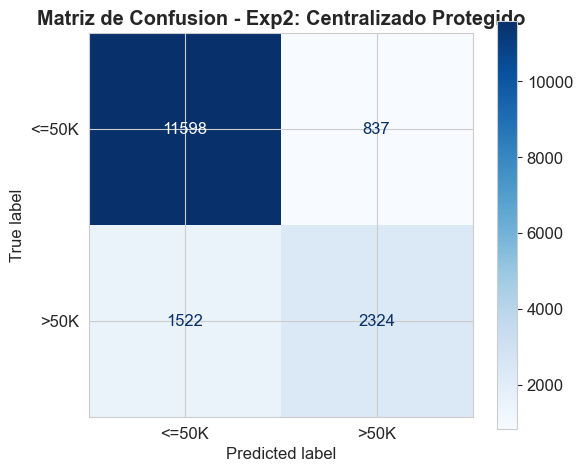

In [24]:
model_exp2 = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model_exp2.fit(X_train_anon, y_train_anon)

# Evaluar
metrics_exp2 = evaluate_model(model_exp2, X_test_anon, y_test_anon, 'Exp2: Centralizado Protegido')

In [25]:
for metric in ['Accuracy','Precision','Recall','F1']:
    print(f'{metric}: Exp1={metrics_exp1[metric]:.4f}, Exp2={metrics_exp2[metric]:.4f}, delta={metrics_exp2[metric]-metrics_exp1[metric]:+.4f}')
print('Utilidad predictiva no equivale a una medida de privacidad.')

Accuracy: Exp1=0.8507, Exp2=0.8551, delta=+0.0044
Precision: Exp1=0.7282, Exp2=0.7352, delta=+0.0071
Recall: Exp1=0.5871, Exp2=0.6043, delta=+0.0172
F1: Exp1=0.6501, Exp2=0.6633, delta=+0.0133
Utilidad predictiva no equivale a una medida de privacidad.


<a id='sec-exp3'></a>
## 8. Experimento 3 — Aprendizaje Federado con Datos Originales

Implementamos aprendizaje federado con:
- **3 clientes** (los datos se dividen de forma equitativa)
- **10 rondas** de entrenamiento federado
- **FedAvg** manual usando `coef_` e `intercept_`

$$W_{global} = \sum_{k=1}^{K} \frac{n_k}{N} W_k$$

Y de forma equivalente para el intercepto.

La partición con `StratifiedKFold` mantiene proporciones de clase muy similares entre clientes, por lo que este experimento representa un escenario aproximadamente IID. No evalúa heterogeneidad Non-IID.

In [26]:
def split_data_clients(X,y,n_clients=3,seed=SEED):
    skf=StratifiedKFold(n_splits=n_clients,shuffle=True,random_state=seed)
    return [(X[idx],y[idx]) for _,idx in skf.split(X,y)]
def fedavg(client_models,client_sizes):
    total=sum(client_sizes)
    return (sum((n/total)*m.coef_ for m,n in zip(client_models,client_sizes)),sum((n/total)*m.intercept_ for m,n in zip(client_models,client_sizes)))

In [27]:
clients_preview=split_data_clients(X_train,y_train,3,SEED)
client_sizes_preview=[len(yc) for _,yc in clients_preview]
fedavg_weights_preview=[n/sum(client_sizes_preview) for n in client_sizes_preview]
assert len(clients_preview)==3 and sum(client_sizes_preview)==len(y_train)
assert np.isclose(sum(fedavg_weights_preview),1.0)
print('Pesos FedAvg:', [round(w,6) for w in fedavg_weights_preview], '| suma:', sum(fedavg_weights_preview))
for i,(_,yc) in enumerate(clients_preview,1): print(f'Cliente {i}: {len(yc)} muestras; clase 1={yc.mean():.4f}')

Pesos FedAvg: [0.333344, 0.333344, 0.333313] | suma: 1.0
Cliente 1: 10854 muestras; clase 1=0.2408
Cliente 2: 10854 muestras; clase 1=0.2408
Cliente 3: 10853 muestras; clase 1=0.2408


In [28]:
def run_federated_learning(X_train_data, y_train_data, X_test_data, y_test_data,
                           n_clients=3, n_rounds=10, seed=42,
                           noise_func=None, experiment_name='FL'):
    """
    Ejecuta aprendizaje federado completo.
    
    Args:
        noise_func: funcion opcional que recibe (coef, intercept) y retorna
                    versiones con ruido. Usado en Exp5.
    
    Returns:
        global_model, round_metrics (lista de metricas por ronda)
    """
    clients = split_data_clients(X_train_data, y_train_data, n_clients, seed)
    client_sizes = [len(c[1]) for c in clients]
    
    print(f'\n{"=" * 60}')
    print(f'  {experiment_name}')
    print(f'{"=" * 60}')
    print(f'Numero de clientes: {n_clients}')
    print(f'Muestras por cliente: {client_sizes}')
    print(f'Total de muestras: {sum(client_sizes)}')
    print(f'Numero de rondas: {n_rounds}')
    
    n_features = X_train_data.shape[1]
    global_coef = np.zeros((1, n_features))
    global_intercept = np.zeros(1)
    
    round_metrics = []
    
    for round_num in range(1, n_rounds + 1):
        client_models = []
        
        for k, (X_k, y_k) in enumerate(clients):
            local_model = LogisticRegression(max_iter=1000, random_state=SEED,
                                           solver='lbfgs', warm_start=True)
            if round_num > 1:
                local_model.coef_ = global_coef.copy()
                local_model.intercept_ = global_intercept.copy()
                local_model.classes_ = np.array([0, 1])
                local_model.n_features_in_ = n_features
            local_model.fit(X_k, y_k)
            
            client_models.append(local_model)
        
        if noise_func is not None:
            noisy_models = []
            for model in client_models:
                noisy_coef, noisy_intercept = noise_func(model.coef_.copy(), model.intercept_.copy())
                noisy_model = copy.deepcopy(model)
                noisy_model.coef_ = noisy_coef
                noisy_model.intercept_ = noisy_intercept
                noisy_models.append(noisy_model)
            global_coef, global_intercept = fedavg(noisy_models, client_sizes)
        else:
            # FedAvg normal
            global_coef, global_intercept = fedavg(client_models, client_sizes)
        
        global_model = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')
        global_model.coef_ = global_coef.copy()
        global_model.intercept_ = global_intercept.copy()
        global_model.classes_ = np.array([0, 1])
        global_model.n_features_in_ = n_features
        
        # Evaluar modelo global
        y_pred = global_model.predict(X_test_data)
        round_metric = {
            'Round': round_num,
            'Accuracy': accuracy_score(y_test_data, y_pred),
            'Precision': precision_score(y_test_data, y_pred, zero_division=0),
            'Recall': recall_score(y_test_data, y_pred, zero_division=0),
            'F1': f1_score(y_test_data, y_pred, zero_division=0)
        }
        round_metrics.append(round_metric)
        
        print(f'  Ronda {round_num:2d}: Acc={round_metric["Accuracy"]:.4f}, '
              f'Prec={round_metric["Precision"]:.4f}, '
              f'Rec={round_metric["Recall"]:.4f}, '
              f'F1={round_metric["F1"]:.4f}')
    
    return global_model, round_metrics

print('Funcion run_federated_learning definida.')

Funcion run_federated_learning definida.


In [29]:
model_exp3, rounds_exp3 = run_federated_learning(
    X_train, y_train, X_test, y_test,
    n_clients=3, n_rounds=10,
    experiment_name='Exp3: Federado con Datos Originales'
)


  Exp3: Federado con Datos Originales
Numero de clientes: 3
Muestras por cliente: [10854, 10854, 10853]
Total de muestras: 32561
Numero de rondas: 10
  Ronda  1: Acc=0.8517, Prec=0.7317, Rec=0.5879, F1=0.6520
  Ronda  2: Acc=0.8519, Prec=0.7323, Rec=0.5881, F1=0.6523
  Ronda  3: Acc=0.8517, Prec=0.7318, Rec=0.5874, F1=0.6517
  Ronda  4: Acc=0.8516, Prec=0.7314, Rec=0.5876, F1=0.6517
  Ronda  5: Acc=0.8518, Prec=0.7321, Rec=0.5876, F1=0.6520
  Ronda  6: Acc=0.8518, Prec=0.7320, Rec=0.5879, F1=0.6521
  Ronda  7: Acc=0.8517, Prec=0.7320, Rec=0.5874, F1=0.6518
  Ronda  8: Acc=0.8515, Prec=0.7313, Rec=0.5874, F1=0.6515
  Ronda  9: Acc=0.8519, Prec=0.7320, Rec=0.5881, F1=0.6522
  Ronda 10: Acc=0.8516, Prec=0.7311, Rec=0.5881, F1=0.6519



  Resultados: Exp3: Federado Original
      Accuracy: 0.8516
     Precision: 0.7311
        Recall: 0.5881
            F1: 0.6519

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     12435
        >50K       0.73      0.59      0.65      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.76      0.78     16281
weighted avg       0.84      0.85      0.85     16281



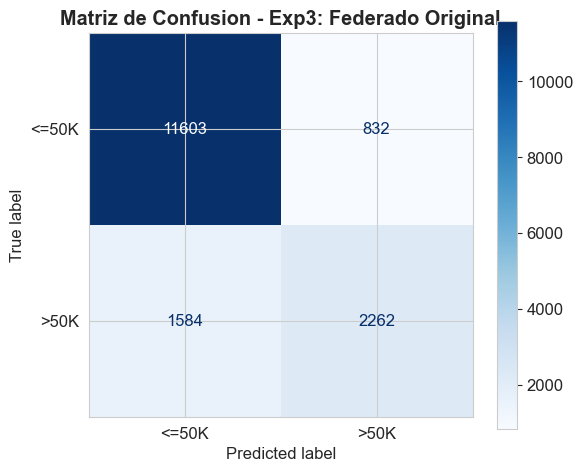


Coeficientes globales (coef_): shape=(1, 105)
Intercepto global (intercept_): [-3.037962]


In [30]:
metrics_exp3 = evaluate_model(model_exp3, X_test, y_test, 'Exp3: Federado Original')

print(f'\nCoeficientes globales (coef_): shape={model_exp3.coef_.shape}')
print(f'Intercepto global (intercept_): {model_exp3.intercept_}')

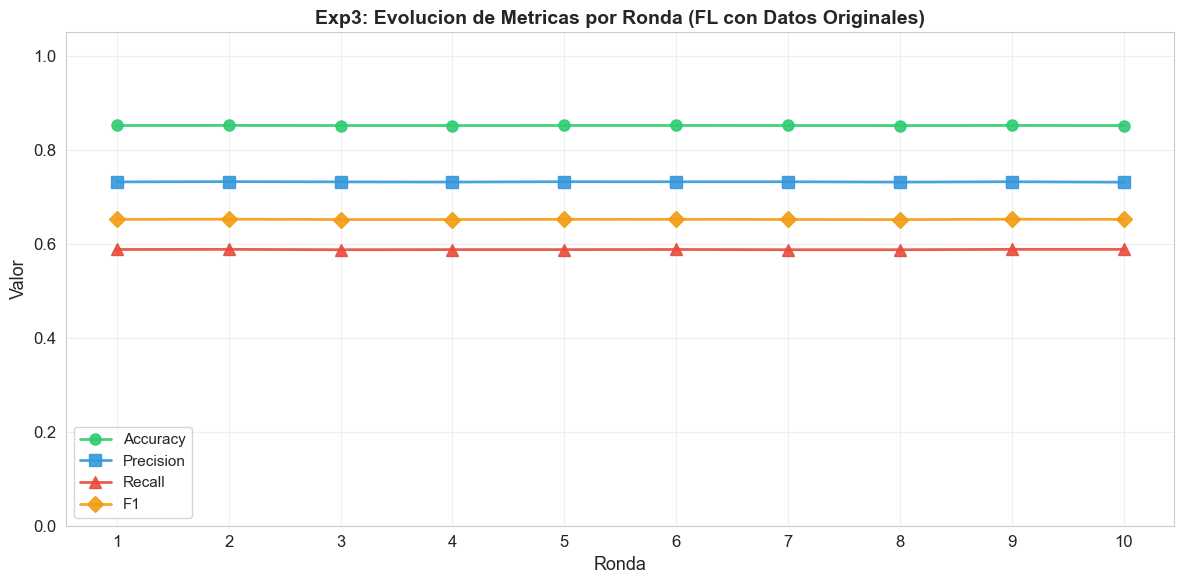

In [31]:
rounds_df = pd.DataFrame(rounds_exp3)

fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_plot = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
markers = ['o', 's', '^', 'D']

for metric, color, marker in zip(metrics_to_plot, colors_plot, markers):
    ax.plot(rounds_df['Round'], rounds_df[metric],
            color=color, marker=marker, linewidth=2, markersize=8,
            label=metric, alpha=0.9)

ax.set_xlabel('Ronda', fontsize=13)
ax.set_ylabel('Valor', fontsize=13)
ax.set_title('Exp3: Evolucion de Metricas por Ronda (FL con Datos Originales)',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='sec-exp4'></a>
## 9. Experimento 4 — Datos Sintéticos + Aprendizaje Federado

Generamos datos sintéticos utilizando **Gaussian Copula** (del paquete SDV) y luego realizamos aprendizaje federado con estos datos sintéticos.

Pasos:
1. Generar datos sintéticos a partir del dataset original
2. Comparar distribuciones originales vs sintéticas
3. Distribuir datos sintéticos entre 3 clientes
4. Ejecutar FL con misma configuración del Exp3

In [32]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata
from sdv.evaluation.single_table import evaluate_quality
import sdv, sklearn, sys
print('Python:', sys.version.split()[0], '| NumPy:', np.__version__, '| Pandas:', pd.__version__, '| sklearn:', sklearn.__version__, '| SDV:', sdv.__version__, '| seed:', SEED)
train_for_synth=train_clean.drop(columns=['income_binary'])
metadata=Metadata.detect_from_dataframe(data=train_for_synth)
synthesizer=GaussianCopulaSynthesizer(metadata); synthesizer.fit(train_for_synth)
synthetic_data=synthesizer.sample(num_rows=len(train_clean)); synthetic_data['income_binary']=synthetic_data.income.map(label_map)
quality_report=evaluate_quality(real_data=train_for_synth,synthetic_data=synthetic_data[train_for_synth.columns],metadata=metadata)
print('Puntaje de calidad SDV:',quality_report.get_score())
display(quality_report.get_properties())
display(quality_report.get_details(property_name='Column Shapes'))
display(quality_report.get_details(property_name='Column Pair Trends'))
real_sig=set(train_for_synth.astype('string').fillna('<NA>').agg('|'.join,axis=1))
synth_sig=set(synthetic_data[train_for_synth.columns].astype('string').fillna('<NA>').agg('|'.join,axis=1))
print('Duplicados sinteticos:',synthetic_data.duplicated(subset=train_for_synth.columns).sum())
print('Coincidencias exactas:',len(real_sig & synth_sig),'(comprobacion basica)')

Python: 3.14.0 | NumPy: 2.3.5 | Pandas: 2.3.3 | sklearn: 1.8.0 | SDV: 1.38.5 | seed: 42


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generating report ...

(1/4) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 89.02it/s]|
Column Shapes Score: 87.57%

(2/4) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 134.68it/s]|
Column Pair Trends Score: 75.31%

(3/4) Evaluating Cardinality: N/A
This property does not apply to single-table data.

(4/4) Evaluating Intertable Trends: N/A
This property does not apply to single-table data.

Overall Score (Average): 81.44%

Puntaje de calidad SDV: 0.814390926207844


,Property,Score
0,Column Shapes,0.875712
1,Column Pair Trends,0.753069


,Table,Column,Metric,Score
0,table,age,KSComplement,0.981082
1,table,workclass,TVComplement,0.990493
2,table,fnlwgt,KSComplement,0.955223
3,table,education,TVComplement,0.994533
4,table,education-num,KSComplement,0.860723
5,table,marital-status,TVComplement,0.997574
6,table,occupation,TVComplement,0.995285
7,table,relationship,TVComplement,0.996591
8,table,race,TVComplement,0.997666
9,table,sex,TVComplement,0.998741


,Table,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,table,age,workclass,ContingencySimilarity,NaN,NaN,NaN,0.119135,False
1,table,age,fnlwgt,CorrelationSimilarity,NaN,-0.076646,NaN,NaN,False
2,table,age,education,ContingencySimilarity,NaN,NaN,NaN,0.107874,False
3,table,age,education-num,CorrelationSimilarity,NaN,0.036527,NaN,NaN,False
4,table,age,marital-status,ContingencySimilarity,NaN,NaN,NaN,0.283330,False
...,...,...,...,...,...,...,...,...,...
100,table,capital-loss,native-country,ContingencySimilarity,NaN,NaN,NaN,0.035836,False
101,table,capital-loss,income,ContingencySimilarity,NaN,NaN,NaN,0.201541,False
102,table,hours-per-week,native-country,ContingencySimilarity,NaN,NaN,NaN,0.043797,False
103,table,hours-per-week,income,ContingencySimilarity,NaN,NaN,NaN,0.276110,False


Duplicados sinteticos: 0
Coincidencias exactas: 0 (comprobacion basica)


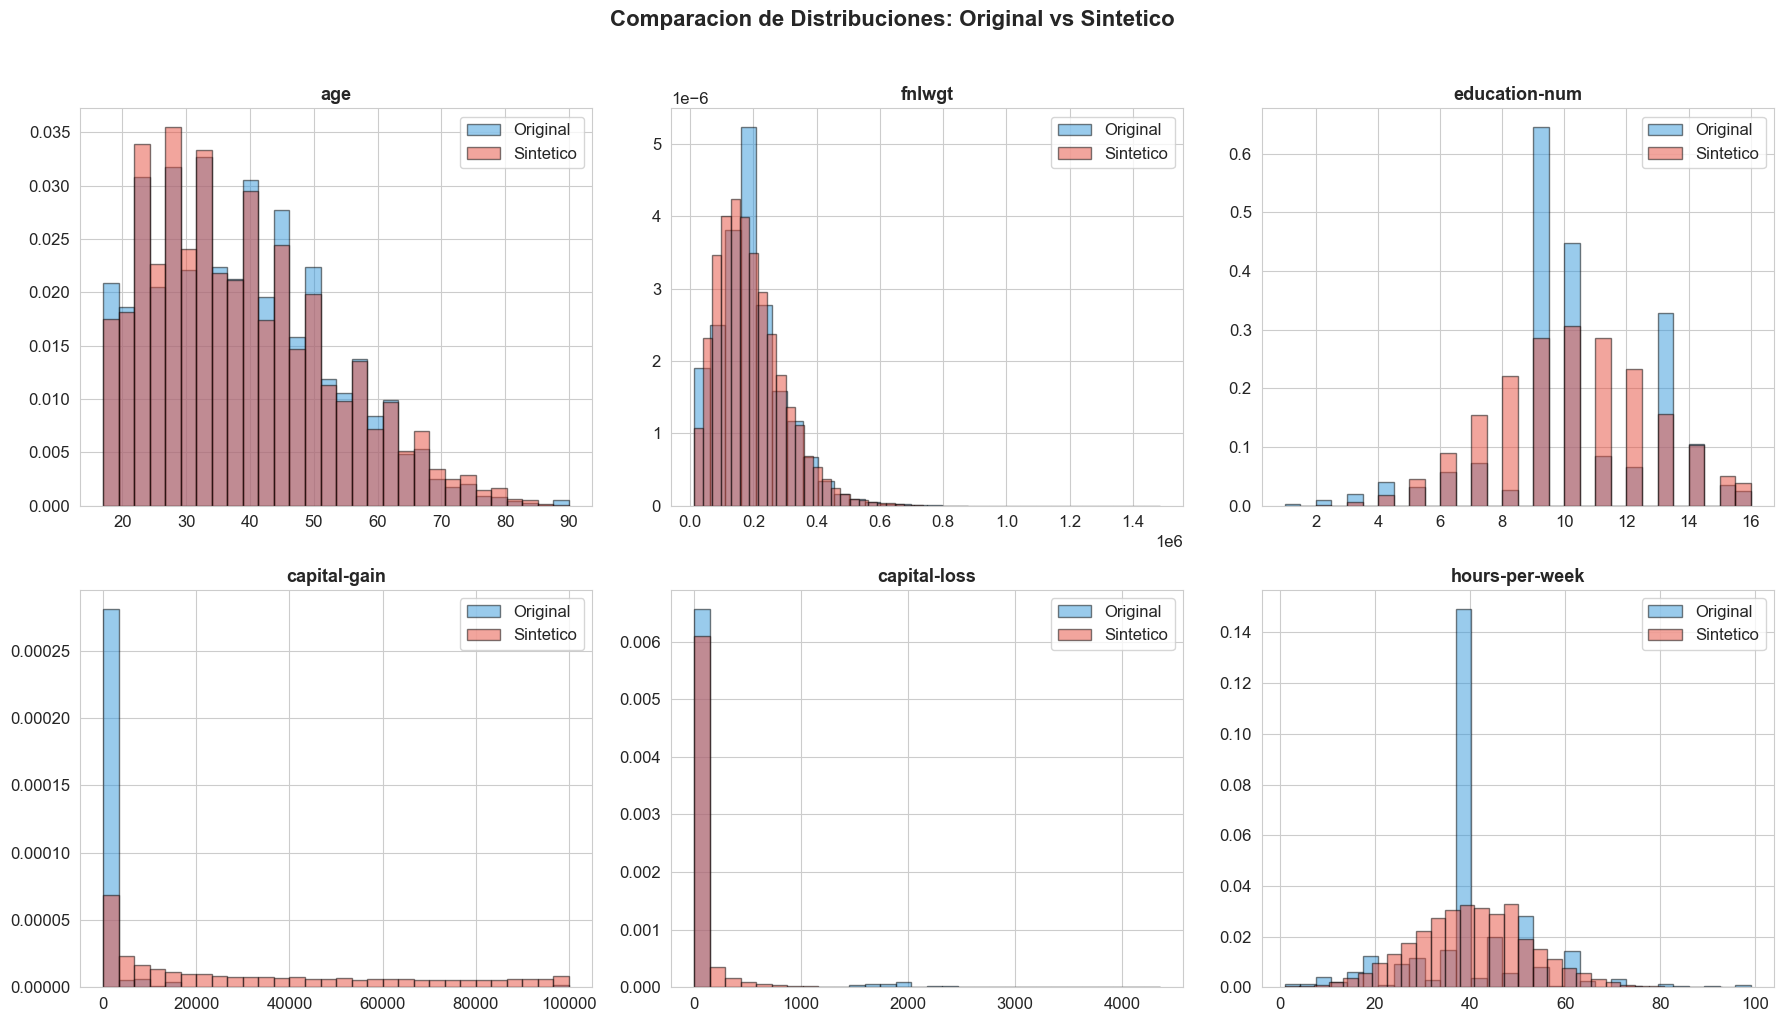

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(train_clean[col], bins=30, alpha=0.5, label='Original',
                 color='#3498db', edgecolor='black', density=True)
    axes[i].hist(synthetic_data[col], bins=30, alpha=0.5, label='Sintetico',
                 color='#e74c3c', edgecolor='black', density=True)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()

plt.suptitle('Comparacion de Distribuciones: Original vs Sintetico',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
print('Proporcion de clases:')
print(f'  Original:  {train_clean["income"].value_counts(normalize=True).to_dict()}')
print(f'  Sintetico: {synthetic_data["income"].value_counts(normalize=True).to_dict()}')

# Comparar estadisticas
print('\nEstadisticas comparativas (media):')
print(f'{"Variable":<18} {"Original":>10} {"Sintetico":>10} {"Diferencia":>12}')
print('-' * 52)
for col in numerical_cols:
    orig_mean = train_clean[col].mean()
    synt_mean = synthetic_data[col].mean()
    diff = synt_mean - orig_mean
    print(f'{col:<18} {orig_mean:>10.2f} {synt_mean:>10.2f} {diff:>+10.2f}')

print('\nDistribucion de sex:')
print(f'  Original:  {dict(train_clean["sex"].value_counts(normalize=True))}')
print(f'  Sintetico: {dict(synthetic_data["sex"].value_counts(normalize=True))}')

Proporcion de clases:
  Original:  {'<=50K': 0.7591904425539756, '>50K': 0.2408095574460244}
  Sintetico: {'<=50K': 0.7528638555326925, '>50K': 0.24713614446730753}

Estadisticas comparativas (media):
Variable             Original  Sintetico   Diferencia
----------------------------------------------------
age                     38.58      38.63      +0.05
fnlwgt              189778.37  189578.34    -200.02
education-num           10.08      10.08      +0.00
capital-gain          1077.65   32830.45  +31752.80
capital-loss            87.30      63.40     -23.90
hours-per-week          40.44      40.45      +0.01

Distribucion de sex:
  Original:  {'Male': np.float64(0.6692054912318418), 'Female': np.float64(0.33079450876815825)}
  Sintetico: {'Male': np.float64(0.6679463161450815), 'Female': np.float64(0.33205368385491846)}


In [35]:
synthetic_clean=synthetic_data.dropna(subset=['income']).reset_index(drop=True)
synthetic_clean['income_binary']=synthetic_clean.income.map(label_map)
synthetic_clean=synthetic_clean.dropna(subset=['income_binary']).reset_index(drop=True)
X_train_synth=preprocessor.transform(synthetic_clean[numerical_cols+categorical_cols])
y_train_synth=synthetic_clean.income_binary.astype(int).to_numpy()
X_test_synth=X_test
assert X_train_synth.shape[1]==X_train.shape[1]
print('Synthetic train y test comparten espacio:',X_train_synth.shape,X_test_synth.shape)

Synthetic train y test comparten espacio: (32561, 105) (16281, 105)


In [36]:
model_exp4, rounds_exp4 = run_federated_learning(
    X_train_synth, y_train_synth, X_test_synth, y_test,
    n_clients=3, n_rounds=10,
    experiment_name='Exp4: Federado con Datos Sinteticos'
)


  Exp4: Federado con Datos Sinteticos
Numero de clientes: 3
Muestras por cliente: [10854, 10854, 10853]
Total de muestras: 32561
Numero de rondas: 10
  Ronda  1: Acc=0.7743, Prec=0.8583, Rec=0.0536, F1=0.1008
  Ronda  2: Acc=0.7743, Prec=0.8583, Rec=0.0536, F1=0.1008
  Ronda  3: Acc=0.7743, Prec=0.8613, Rec=0.0533, F1=0.1004
  Ronda  4: Acc=0.7742, Prec=0.8602, Rec=0.0528, F1=0.0995
  Ronda  5: Acc=0.7741, Prec=0.8590, Rec=0.0523, F1=0.0985
  Ronda  6: Acc=0.7743, Prec=0.8608, Rec=0.0530, F1=0.0999
  Ronda  7: Acc=0.7745, Prec=0.8631, Rec=0.0541, F1=0.1018
  Ronda  8: Acc=0.7744, Prec=0.8619, Rec=0.0536, F1=0.1009
  Ronda  9: Acc=0.7743, Prec=0.8608, Rec=0.0530, F1=0.0999
  Ronda 10: Acc=0.7743, Prec=0.8608, Rec=0.0530, F1=0.0999



  Resultados: Exp4: Federado Sintetico
      Accuracy: 0.7743
     Precision: 0.8608
        Recall: 0.0530
            F1: 0.0999

              precision    recall  f1-score   support

       <=50K       0.77      1.00      0.87     12435
        >50K       0.86      0.05      0.10      3846

    accuracy                           0.77     16281
   macro avg       0.82      0.53      0.49     16281
weighted avg       0.79      0.77      0.69     16281



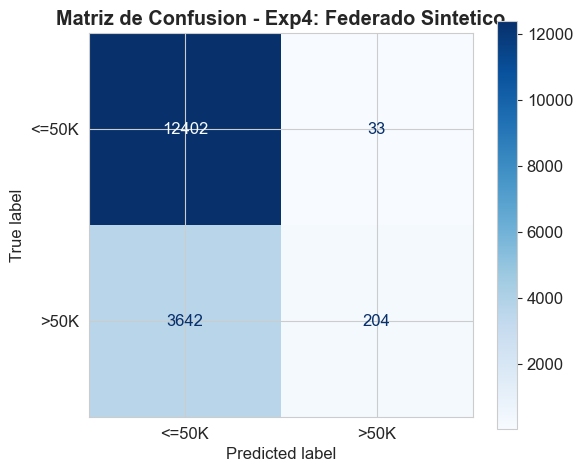

In [37]:
metrics_exp4 = evaluate_model(model_exp4, X_test_synth, y_test, 'Exp4: Federado Sintetico')

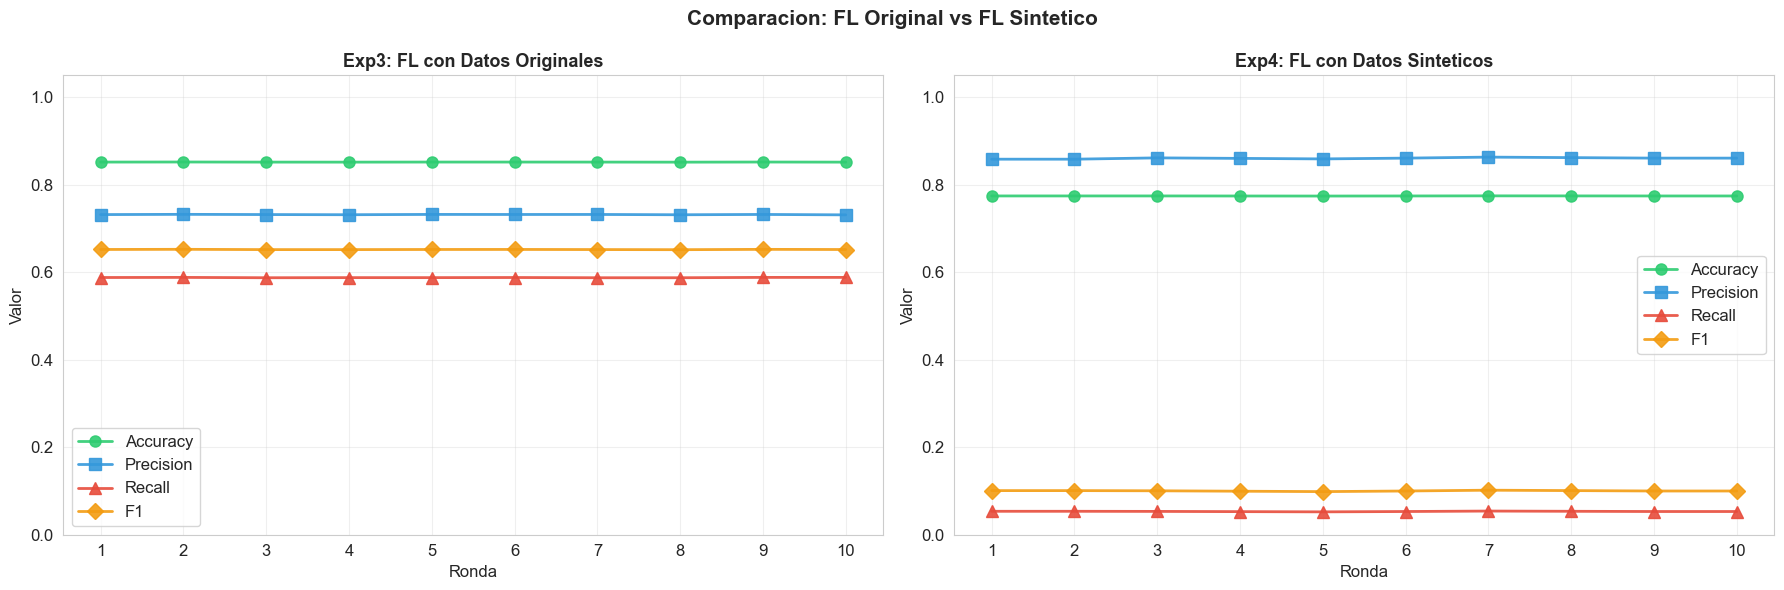

In [38]:
rounds_df4 = pd.DataFrame(rounds_exp4)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Exp3 (Original)
for metric, color, marker in zip(metrics_to_plot, colors_plot, markers):
    axes[0].plot(rounds_df['Round'], rounds_df[metric],
                 color=color, marker=marker, linewidth=2, markersize=8,
                 label=metric, alpha=0.9)
axes[0].set_title('Exp3: FL con Datos Originales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ronda')
axes[0].set_ylabel('Valor')
axes[0].legend()
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Exp4 (Sintetico)
for metric, color, marker in zip(metrics_to_plot, colors_plot, markers):
    axes[1].plot(rounds_df4['Round'], rounds_df4[metric],
                 color=color, marker=marker, linewidth=2, markersize=8,
                 label=metric, alpha=0.9)
axes[1].set_title('Exp4: FL con Datos Sinteticos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ronda')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion: FL Original vs FL Sintetico', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='sec-exp5'></a>
## 10. Experimento 5 — Protección de Parámetros + Aprendizaje Federado

Repetimos el Exp3 usando datos originales, pero los clientes protegen los parámetros antes de enviarlos al servidor:

$$\widetilde{W}_k = W_k + \epsilon$$
$$\widetilde{b}_k = b_k + \epsilon$$

donde $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

Probamos **tres niveles de perturbación**:
- **Bajo**: $\sigma = 0.01$
- **Medio**: $\sigma = 0.1$
- **Alto**: $\sigma = 1.0$

> **Nota:** Añadir ruido gaussiano no constituye automáticamente Differential Privacy formalmente, ya que no se implementa un mecanismo con garantías $(\varepsilon, \delta)$-DP. Es simplemente una técnica de perturbación de parámetros.

In [39]:
def make_noise_func(sigma,seed=SEED):
    rng=np.random.default_rng(seed)
    def noise_func(coef,intercept):
        return coef+rng.normal(0,sigma,size=coef.shape),intercept+rng.normal(0,sigma,size=intercept.shape)
    return noise_func
noise_levels={'Bajo (s=0.01)':0.01,'Medio (s=0.1)':0.1,'Alto (s=1.0)':1.0}
print('Seed reproducible:',SEED,'|',noise_levels)

Seed reproducible: 42 | {'Bajo (s=0.01)': 0.01, 'Medio (s=0.1)': 0.1, 'Alto (s=1.0)': 1.0}



  Exp5: FL con Perturbacion Bajo (s=0.01)
Numero de clientes: 3
Muestras por cliente: [10854, 10854, 10853]
Total de muestras: 32561
Numero de rondas: 10
  Ronda  1: Acc=0.8523, Prec=0.7310, Rec=0.5928, F1=0.6547
  Ronda  2: Acc=0.8516, Prec=0.7303, Rec=0.5894, F1=0.6524
  Ronda  3: Acc=0.8517, Prec=0.7333, Rec=0.5848, F1=0.6507
  Ronda  4: Acc=0.8517, Prec=0.7333, Rec=0.5848, F1=0.6507
  Ronda  5: Acc=0.8515, Prec=0.7338, Rec=0.5827, F1=0.6496
  Ronda  6: Acc=0.8520, Prec=0.7303, Rec=0.5920, F1=0.6539
  Ronda  7: Acc=0.8519, Prec=0.7342, Rec=0.5845, F1=0.6508
  Ronda  8: Acc=0.8519, Prec=0.7293, Rec=0.5933, F1=0.6543
  Ronda  9: Acc=0.8515, Prec=0.7327, Rec=0.5845, F1=0.6503
  Ronda 10: Acc=0.8519, Prec=0.7294, Rec=0.5928, F1=0.6540

  Resultados: Exp5: Bajo (s=0.01)
      Accuracy: 0.8519
     Precision: 0.7294
        Recall: 0.5928
            F1: 0.6540

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     12435
        >50K      

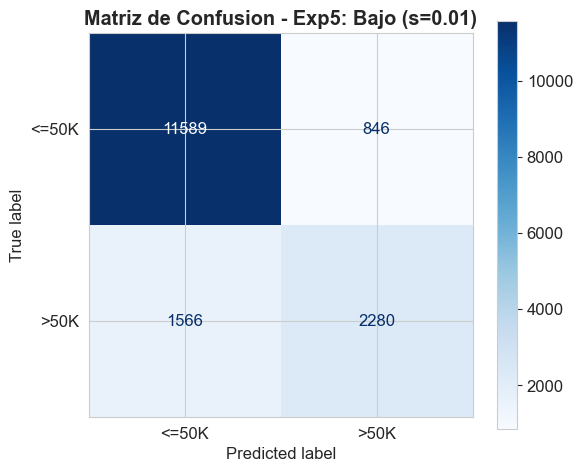


  Exp5: FL con Perturbacion Medio (s=0.1)
Numero de clientes: 3
Muestras por cliente: [10854, 10854, 10853]
Total de muestras: 32561
Numero de rondas: 10
  Ronda  1: Acc=0.8514, Prec=0.7163, Rec=0.6144, F1=0.6614
  Ronda  2: Acc=0.8501, Prec=0.7247, Rec=0.5892, F1=0.6499
  Ronda  3: Acc=0.8504, Prec=0.7510, Rec=0.5489, F1=0.6342
  Ronda  4: Acc=0.8491, Prec=0.7411, Rec=0.5551, F1=0.6348
  Ronda  5: Acc=0.8484, Prec=0.7493, Rec=0.5385, F1=0.6266
  Ronda  6: Acc=0.8514, Prec=0.7142, Rec=0.6180, F1=0.6627
  Ronda  7: Acc=0.8495, Prec=0.7475, Rec=0.5481, F1=0.6325
  Ronda  8: Acc=0.8509, Prec=0.7061, Rec=0.6321, F1=0.6670
  Ronda  9: Acc=0.8496, Prec=0.7426, Rec=0.5559, F1=0.6358
  Ronda 10: Acc=0.8498, Prec=0.7052, Rec=0.6256, F1=0.6630

  Resultados: Exp5: Medio (s=0.1)
      Accuracy: 0.8498
     Precision: 0.7052
        Recall: 0.6256
            F1: 0.6630

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90     12435
        >50K      

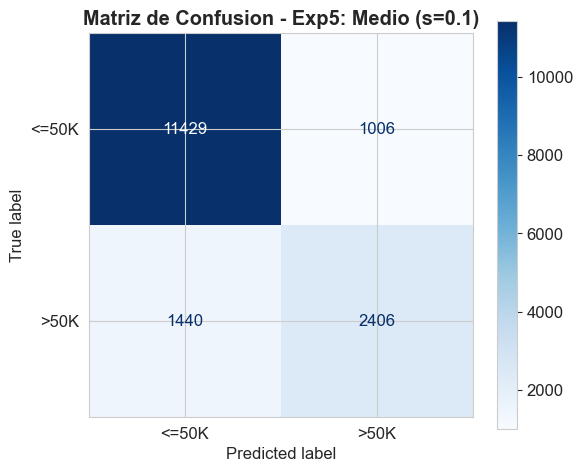


  Exp5: FL con Perturbacion Alto (s=1.0)
Numero de clientes: 3
Muestras por cliente: [10854, 10854, 10853]
Total de muestras: 32561
Numero de rondas: 10
  Ronda  1: Acc=0.8116, Prec=0.5792, Rec=0.7405, F1=0.6500
  Ronda  2: Acc=0.7983, Prec=0.5704, Rec=0.5920, F1=0.5810
  Ronda  3: Acc=0.8160, Prec=0.7577, Rec=0.3253, F1=0.4552
  Ronda  4: Acc=0.7807, Prec=0.5545, Rec=0.3651, F1=0.4403
  Ronda  5: Acc=0.8106, Prec=0.7677, Rec=0.2845, F1=0.4151
  Ronda  6: Acc=0.7650, Prec=0.5016, Rec=0.7964, F1=0.6156
  Ronda  7: Acc=0.7982, Prec=0.6691, Rec=0.2886, F1=0.4033
  Ronda  8: Acc=0.7888, Prec=0.5350, Rec=0.8107, F1=0.6446
  Ronda  9: Acc=0.7893, Prec=0.5817, Rec=0.3851, F1=0.4634
  Ronda 10: Acc=0.7433, Prec=0.4752, Rec=0.8287, F1=0.6040

  Resultados: Exp5: Alto (s=1.0)
      Accuracy: 0.7433
     Precision: 0.4752
        Recall: 0.8287
            F1: 0.6040

              precision    recall  f1-score   support

       <=50K       0.93      0.72      0.81     12435
        >50K       0

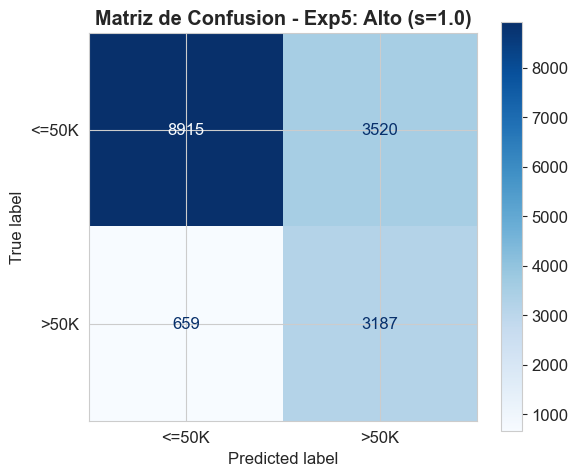

In [40]:
exp5_results = {}
exp5_rounds = {}

for name, sigma in noise_levels.items():
    noise_func = make_noise_func(sigma)
    model, rounds = run_federated_learning(
        X_train, y_train, X_test, y_test,
        n_clients=3, n_rounds=10,
        noise_func=noise_func,
        experiment_name=f'Exp5: FL con Perturbacion {name}'
    )
    exp5_results[name] = evaluate_model(model, X_test, y_test, f'Exp5: {name}')
    exp5_rounds[name] = rounds

In [41]:
metrics_exp5 = exp5_results['Medio (s=0.1)']

print('\n' + '=' * 60)
print('  Resumen Exp5: Impacto del nivel de perturbacion')
print('=' * 60)
print(f'{"Nivel":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 62)
for name, metrics in exp5_results.items():
    print(f'{name:<20} {metrics["Accuracy"]:>10.4f} {metrics["Precision"]:>10.4f} '
          f'{metrics["Recall"]:>10.4f} {metrics["F1"]:>10.4f}')
print(f'{"Sin ruido (Exp3)":<20} {metrics_exp3["Accuracy"]:>10.4f} {metrics_exp3["Precision"]:>10.4f} '
      f'{metrics_exp3["Recall"]:>10.4f} {metrics_exp3["F1"]:>10.4f}')


  Resumen Exp5: Impacto del nivel de perturbacion
Nivel                  Accuracy  Precision     Recall         F1
--------------------------------------------------------------
Bajo (s=0.01)            0.8519     0.7294     0.5928     0.6540
Medio (s=0.1)            0.8498     0.7052     0.6256     0.6630
Alto (s=1.0)             0.7433     0.4752     0.8287     0.6040
Sin ruido (Exp3)         0.8516     0.7311     0.5881     0.6519


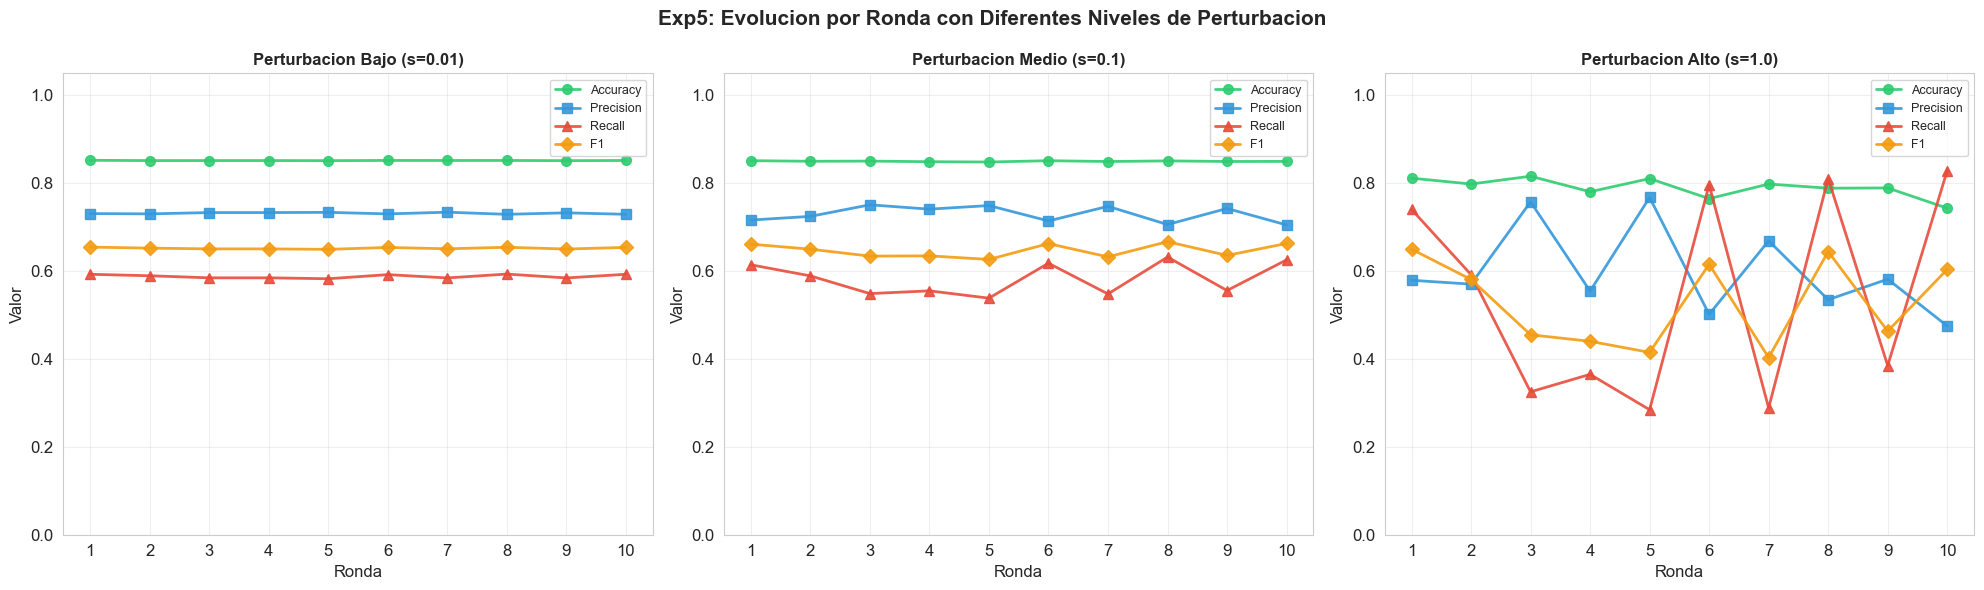

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, rounds_data) in enumerate(exp5_rounds.items()):
    rdf = pd.DataFrame(rounds_data)
    for metric, color, marker in zip(metrics_to_plot, colors_plot, markers):
        axes[idx].plot(rdf['Round'], rdf[metric],
                       color=color, marker=marker, linewidth=2, markersize=7,
                       label=metric, alpha=0.9)
    axes[idx].set_title(f'Perturbacion {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ronda')
    axes[idx].set_ylabel('Valor')
    axes[idx].legend(fontsize=9)
    axes[idx].set_xticks(range(1, 11))
    axes[idx].set_ylim(0, 1.05)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Exp5: Evolucion por Ronda con Diferentes Niveles de Perturbacion',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

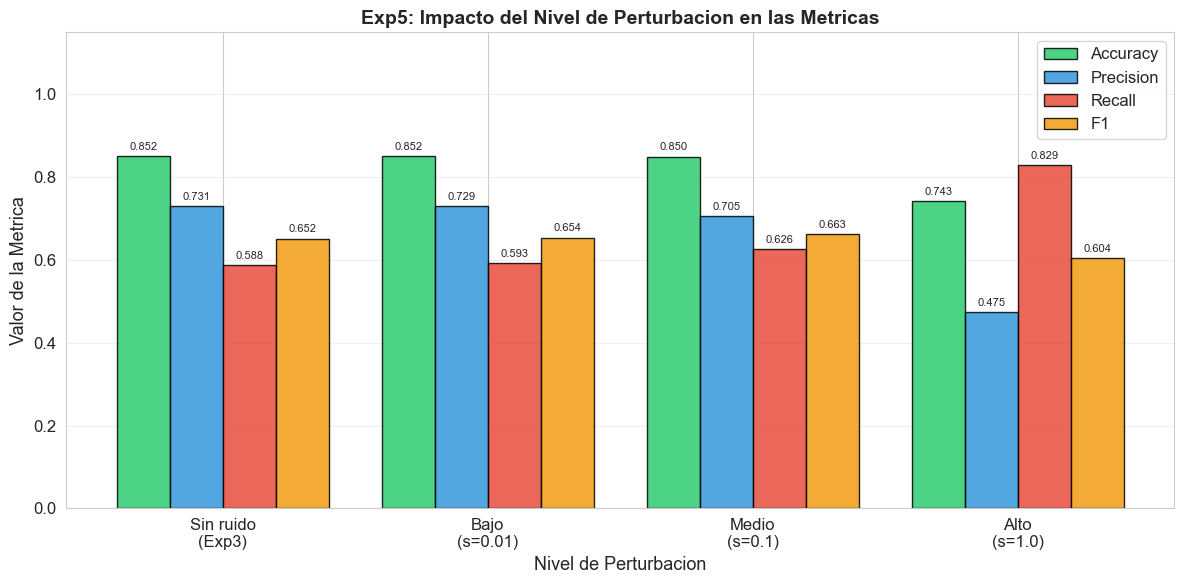

In [43]:
sigma_values = [0, 0.01, 0.1, 1.0]
sigma_labels = ['Sin ruido\n(Exp3)', 'Bajo\n(s=0.01)', 'Medio\n(s=0.1)', 'Alto\n(s=1.0)']

all_metrics_exp5 = [metrics_exp3]
for name in noise_levels.keys():
    all_metrics_exp5.append(exp5_results[name])

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(sigma_labels))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_plot)):
    values = [m[metric] for m in all_metrics_exp5]
    bars = ax.bar(x + i * width, values, width, label=metric, color=color,
                  edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Nivel de Perturbacion', fontsize=13)
ax.set_ylabel('Valor de la Metrica', fontsize=13)
ax.set_title('Exp5: Impacto del Nivel de Perturbacion en las Metricas',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(sigma_labels)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<a id='sec-comparison'></a>
## 11. Comparación Final

Tabla resumen de todos los experimentos.

In [44]:
# Tabla comparativa final
comparison_data = {
    'Escenario': [
        '1. Original - Centralizado',
        '2. Protegido - Centralizado',
        '3. Original - Federado',
        '4. Sintetico - Federado',
        '5. Param. protegidos - Fed. (s=0.01)',
        '5. Param. protegidos - Fed. (s=0.1)',
        '5. Param. protegidos - Fed. (s=1.0)'
    ],
    'Accuracy': [
        metrics_exp1['Accuracy'],
        metrics_exp2['Accuracy'],
        metrics_exp3['Accuracy'],
        metrics_exp4['Accuracy'],
        exp5_results['Bajo (s=0.01)']['Accuracy'],
        exp5_results['Medio (s=0.1)']['Accuracy'],
        exp5_results['Alto (s=1.0)']['Accuracy']
    ],
    'Precision': [
        metrics_exp1['Precision'],
        metrics_exp2['Precision'],
        metrics_exp3['Precision'],
        metrics_exp4['Precision'],
        exp5_results['Bajo (s=0.01)']['Precision'],
        exp5_results['Medio (s=0.1)']['Precision'],
        exp5_results['Alto (s=1.0)']['Precision']
    ],
    'Recall': [
        metrics_exp1['Recall'],
        metrics_exp2['Recall'],
        metrics_exp3['Recall'],
        metrics_exp4['Recall'],
        exp5_results['Bajo (s=0.01)']['Recall'],
        exp5_results['Medio (s=0.1)']['Recall'],
        exp5_results['Alto (s=1.0)']['Recall']
    ],
    'F1': [
        metrics_exp1['F1'],
        metrics_exp2['F1'],
        metrics_exp3['F1'],
        metrics_exp4['F1'],
        exp5_results['Bajo (s=0.01)']['F1'],
        exp5_results['Medio (s=0.1)']['F1'],
        exp5_results['Alto (s=1.0)']['F1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print('\n' + '=' * 80)
print('  TABLA COMPARATIVA FINAL')
print('=' * 80)

styled = comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1'])

display(styled)


  TABLA COMPARATIVA FINAL


,Escenario,Accuracy,Precision,Recall,F1
0,1. Original - Centralizado,0.8507,0.7282,0.5871,0.6501
1,2. Protegido - Centralizado,0.8551,0.7352,0.6043,0.6633
2,3. Original - Federado,0.8516,0.7311,0.5881,0.6519
3,4. Sintetico - Federado,0.7743,0.8608,0.0530,0.0999
4,5. Param. protegidos - Fed. (s=0.01),0.8519,0.7294,0.5928,0.6540
5,5. Param. protegidos - Fed. (s=0.1),0.8498,0.7052,0.6256,0.6630
6,5. Param. protegidos - Fed. (s=1.0),0.7433,0.4752,0.8287,0.6040


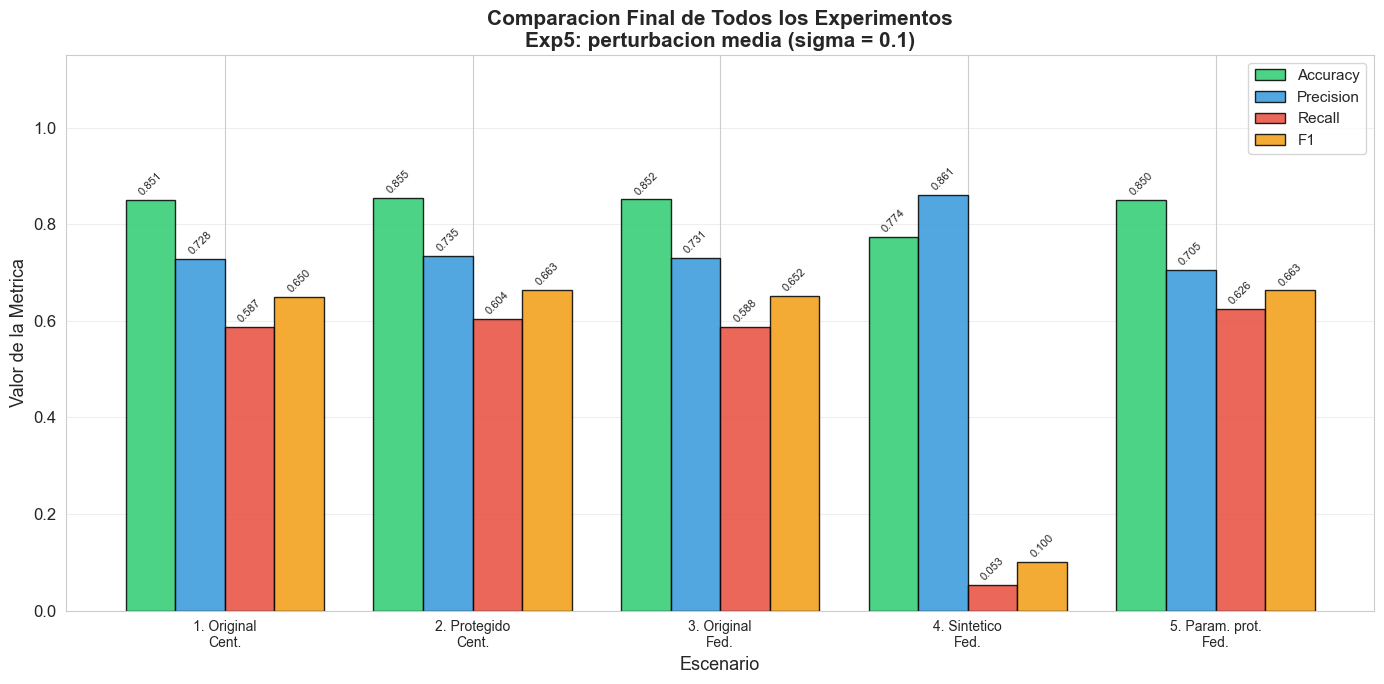

In [45]:
main_scenarios = ['1. Original\nCent.', '2. Protegido\nCent.',
                  '3. Original\nFed.', '4. Sintetico\nFed.',
                  '5. Param. prot.\nFed.']
main_metrics = [metrics_exp1, metrics_exp2, metrics_exp3, metrics_exp4, metrics_exp5]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(main_scenarios))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_plot)):
    values = [m[metric] for m in main_metrics]
    bars = ax.bar(x + i * width, values, width, label=metric, color=color,
                  edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Escenario', fontsize=13)
ax.set_ylabel('Valor de la Metrica', fontsize=13)
ax.set_title('Comparacion Final de Todos los Experimentos\nExp5: perturbacion media (sigma = 0.1)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(main_scenarios, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [46]:
def compare_experiments(name1, metrics1, name2, metrics2):
    print(f'\n{"-" * 60}')
    print(f'  {name1} vs {name2}')
    print(f'{"-" * 60}')
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
        diff = metrics2[metric] - metrics1[metric]
        pct = (diff / metrics1[metric]) * 100 if metrics1[metric] != 0 else 0
        symbol = '+' if diff > 0 else '-' if diff < 0 else '='
        print(f'  {metric:<10}: {metrics1[metric]:.4f} -> {metrics2[metric]:.4f} '
              f'({diff:+.4f}, {pct:+.2f}%) {symbol}')

print('\n' + '=' * 60)
print('  ANALISIS DE COMPARACIONES')
print('=' * 60)

compare_experiments('Exp1 (Original)', metrics_exp1, 'Exp2 (Protegido)', metrics_exp2)

compare_experiments('Exp1 (Centralizado)', metrics_exp1, 'Exp3 (Federado)', metrics_exp3)

compare_experiments('Exp3 (Original FL)', metrics_exp3, 'Exp4 (Sintetico FL)', metrics_exp4)

compare_experiments('Exp3 (FL sin ruido)', metrics_exp3, 'Exp5 (FL con ruido)', metrics_exp5)

compare_experiments('Exp4 (Datos sinteticos)', metrics_exp4, 'Exp5 (Param. protegidos)', metrics_exp5)


  ANALISIS DE COMPARACIONES

------------------------------------------------------------
  Exp1 (Original) vs Exp2 (Protegido)
------------------------------------------------------------
  Accuracy  : 0.8507 -> 0.8551 (+0.0044, +0.52%) +
  Precision : 0.7282 -> 0.7352 (+0.0071, +0.97%) +
  Recall    : 0.5871 -> 0.6043 (+0.0172, +2.92%) +
  F1        : 0.6501 -> 0.6633 (+0.0133, +2.04%) +

------------------------------------------------------------
  Exp1 (Centralizado) vs Exp3 (Federado)
------------------------------------------------------------
  Accuracy  : 0.8507 -> 0.8516 (+0.0009, +0.11%) +
  Precision : 0.7282 -> 0.7311 (+0.0029, +0.40%) +
  Recall    : 0.5871 -> 0.5881 (+0.0010, +0.18%) +
  F1        : 0.6501 -> 0.6519 (+0.0018, +0.28%) +

------------------------------------------------------------
  Exp3 (Original FL) vs Exp4 (Sintetico FL)
------------------------------------------------------------
  Accuracy  : 0.8516 -> 0.7743 (-0.0773, -9.08%) -
  Precision : 0.7311

<a id='sec-questions'></a>
## 12. Preguntas de Análisis

### 1. ¿Qué impacto tuvo la protección sobre el rendimiento?

En esta ejecución, Exp2 no redujo las métricas predictivas respecto de Exp1. Accuracy pasó de 0.8507 a 0.8551 y F1 de 0.6501 a 0.6633; los cambios fueron +0.0044 en Accuracy, +0.0071 en Precision, +0.0172 en Recall y +0.0133 en F1. La singularidad k=1 para la combinación seleccionada de cuasi-identificadores bajó de 8,054 registros (24.74%) a 1,351 (4.15%). Es un indicador descriptivo, no demuestra que la reidentificación sea imposible ni constituye privacidad formal.

### 2. ¿Qué diferencias encontraron entre centralizado y federado?

Exp1 obtuvo Accuracy = 0.8507 y F1 = 0.6501; Exp3 obtuvo 0.8516 y 0.6519, respectivamente. Las diferencias fueron pequeñas (+0.0009 en Accuracy y +0.0018 en F1). Exp3 usó tres clientes con proporciones de clase prácticamente iguales, diez rondas de FedAvg y el mismo conjunto de prueba. El resultado describe esta configuración aproximadamente IID; no demuestra que FL supere en general al entrenamiento centralizado.

### 3. ¿Qué tan similares fueron los datos sintéticos?

SDV reportó una calidad sintética global de 0.8144 (Column Shapes = 0.8757; Column Pair Trends = 0.7531). Las proporciones de clase y varias medias fueron cercanas, pero capital-gain fue una excepción marcada: su media pasó de 1,077.65 a 32,830.45 y su score de forma fue 0.0904. Coherentemente, Exp4 alcanzó Recall = 0.0530 y F1 = 0.0999 para >50K, aunque Precision fue 0.8608. La calidad de SDV no es una medida de privacidad; cero coincidencias exactas solo es una comprobación básica.

### 4. ¿Cómo afectó el ruido de parámetros?

| Configuración | Accuracy | Precision | Recall | F1 |
| --- | ---: | ---: | ---: | ---: |
| Sin ruido (Exp3) | 0.8516 | 0.7311 | 0.5881 | 0.6519 |
| Bajo (sigma = 0.01) | 0.8519 | 0.7294 | 0.5928 | 0.6540 |
| Medio (sigma = 0.1) | 0.8498 | 0.7052 | 0.6256 | 0.6630 |
| Alto (sigma = 1.0) | 0.7433 | 0.4752 | 0.8287 | 0.6040 |

El ruido bajo mantuvo resultados próximos a Exp3; el nivel medio redujo Precision y aumentó Recall y F1 en esta ejecución. El nivel alto cambió sustancialmente el comportamiento: cayó Accuracy y subió Recall. El efecto no fue monotónico en todas las métricas y el ruido no constituye Differential Privacy formal.

### 5. ¿Qué escenario ofrece el mejor equilibrio entre privacidad y utilidad?

Con estos experimentos no se puede establecer un ganador formal en privacidad: no se calculó una garantía cuantitativa ni se evaluaron ataques. En utilidad, sigma = 0.01 quedó cerca de Exp3 y sigma = 0.1 obtuvo el F1 más alto de Exp5 (0.6630); ninguno de esos resultados prueba mayor privacidad. La reducción de singularidad se midió para Exp2 y bajo una combinación concreta de cuasi-identificadores, por lo que no es directamente comparable con la perturbación de parámetros.

### 6. ¿Compartir parámetros garantiza privacidad completa?

No. En FL los registros pueden permanecer en los clientes, pero los parámetros o actualizaciones compartidos pueden revelar información según el modelo de amenaza. Este trabajo no evalúa ataques de inferencia y la perturbación aplicada no incluye los mecanismos necesarios para una garantía formal de Differential Privacy. Por tanto, los resultados no justifican afirmar privacidad completa.


<a id='sec-conclusions'></a>
## 13. Conclusiones

Exp1 estableció el baseline centralizado (Accuracy = 0.8507; F1 = 0.6501). En Exp2 se generalizó age, se suprimió native-country y se agruparon categorías raras. La singularidad observada para los cuasi-identificadores seleccionados bajó de 24.74% a 4.15%; a la vez, F1 pasó a 0.6633. Estos resultados describen esta ejecución y no prueban anonimato ni imposibilidad de reidentificación.

Exp3, con tres clientes aproximadamente IID y diez rondas de FedAvg, alcanzó Accuracy = 0.8516 y F1 = 0.6519, valores cercanos al baseline centralizado. En Exp4, SDV obtuvo calidad global = 0.8144, pero capital-gain presentó score = 0.0904 y una media sintética muy superior a la real. El modelo entrenado con los datos sintéticos tuvo Recall = 0.0530 y F1 = 0.0999 para >50K, lo que muestra que la calidad global no garantiza preservar la utilidad predictiva.

En Exp5, sigma = 0.01 mantuvo métricas próximas a Exp3; sigma = 0.1 produjo F1 = 0.6630; y sigma = 1.0 redujo Accuracy a 0.7433 mientras elevó Recall a 0.8287. La perturbación aplicada es experimental y no proporciona una garantía formal de privacidad diferencial.

En conjunto, la protección de registros, la generación de datos sintéticos y la perturbación de parámetros actúan en etapas distintas. Los resultados de utilidad y la singularidad observada no bastan para ordenar formalmente los escenarios por privacidad. El aprendizaje federado tampoco garantiza privacidad completa; cualquier garantía requiere un modelo de amenaza y mecanismos de privacidad formalmente definidos.
